In [1]:
!pip install -qr requirements.txt

DEPRECATION: Loading egg at /opt/homebrew/Cellar/tbb/2021.12.0/lib/python3.12/site-packages/TBB-0.2-py3.12-macosx-13.0-arm64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.1.1 -> 24.2
[notice] To update, run: /opt/homebrew/opt/python@3.12/bin/python3.12 -m pip install --upgrade pip


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from scipy.io import mmread
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# deep stuff
import torch
from torch_geometric.utils import from_networkx

In [4]:
from src.community_results import community_metrics, plot_communities, community_size_hist
from src.clustering import label_propagation, louvain, leiden, kmeans, optics
from src.DGIModel import DGIModel
from src.GAT import  GAT, contrastive_loss
from src.tune import tune, tune_variance_contrastive

/opt/homebrew/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
data_path = './data'

enron_path = f'{data_path}/email_enron_only.mtx'
univ_path = f'{data_path}/email_univ.edges'

In [6]:
# assume undirected graph
def read_adj_file(file, skip_rows: int = 0):
    lines = []
    with open(file, 'r') as f:
        lines = f.readlines()

    E = np.asarray([l.split() for l in lines[skip_rows:]]).astype(int)
    # index from 0
    E = E - E.min()

    adj = np.zeros((E.max() + 1, E.max() + 1))

    for (u, v) in E:
        adj[u, v] = 1
        adj[v, u] = 1

    return adj

# Load datasets

In [7]:
graphs = dict()

In [8]:
# not in standard mtx format
graphs['univ'] = nx.Graph(read_adj_file(univ_path))
graphs['univ'].number_of_nodes(), graphs['univ'].number_of_edges(), graphs['univ'].is_directed()

(1133, 5451, False)

In [9]:
graphs['enron'] = nx.Graph(mmread(enron_path).toarray())
graphs['enron'].number_of_nodes(), graphs['enron'].number_of_edges(), graphs['enron'].is_directed()

(143, 623, False)

In [10]:
graphs['karate'] = nx.karate_club_graph()
graphs['karate'].number_of_nodes(), graphs['karate'] .number_of_edges(), graphs['karate'].is_directed()

(34, 78, False)

# Select Dataset

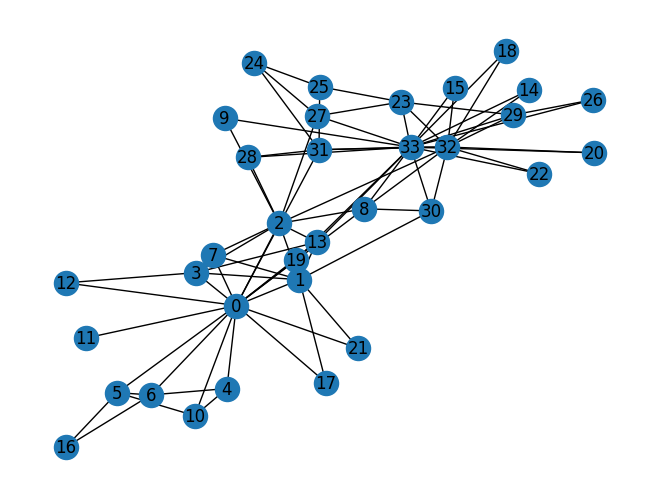

In [11]:
sel_graph = 'karate'
g = graphs[sel_graph]
nx.draw(g, with_labels=True)

# Apply graph based clustering

## Label Propagation

### Hyperparameter selection

2 approaches will be considered for label propagation:
1. Single run label propagation.
2. Label propagation with aggregation on multiple runs.

In [12]:
lp_trials = []

Single run experiment:

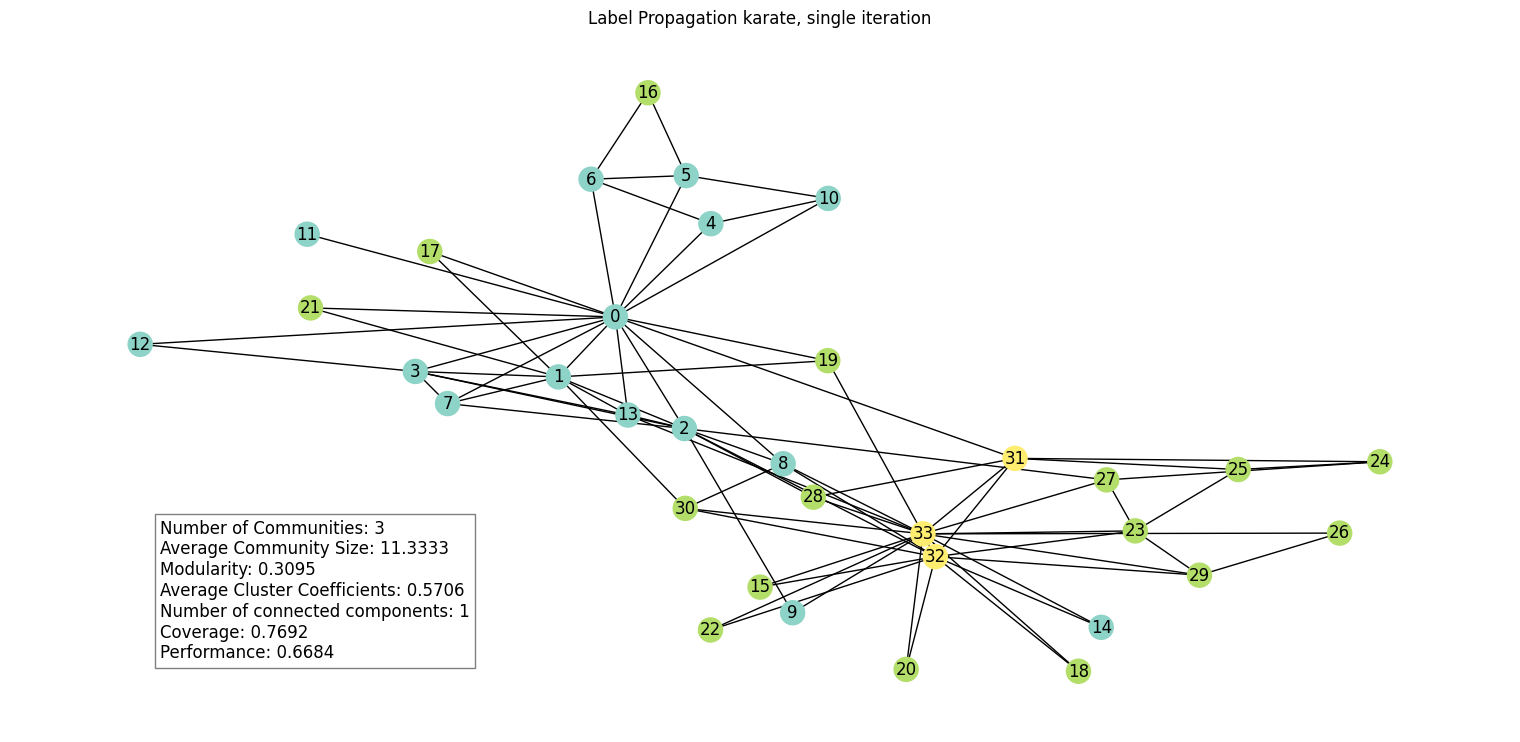

In [13]:
# single run
lp_labels = label_propagation(g)

# Calculate metrics for LP
lp_metrics = community_metrics(g, lp_labels)
lp_trials.append({**lp_metrics, 'Iterations': 1})
plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, single iteration", metrics=lp_metrics)

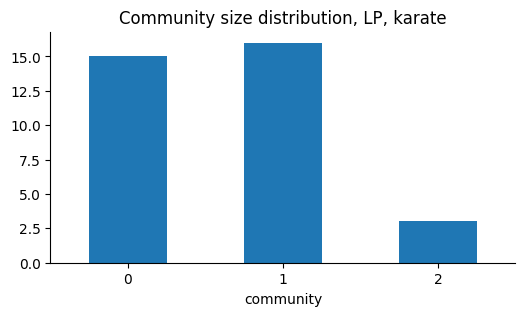

In [14]:
community_size_hist(lp_labels, title=f"Community size distribution, LP, {sel_graph}")

Experiment with 5 iterations:

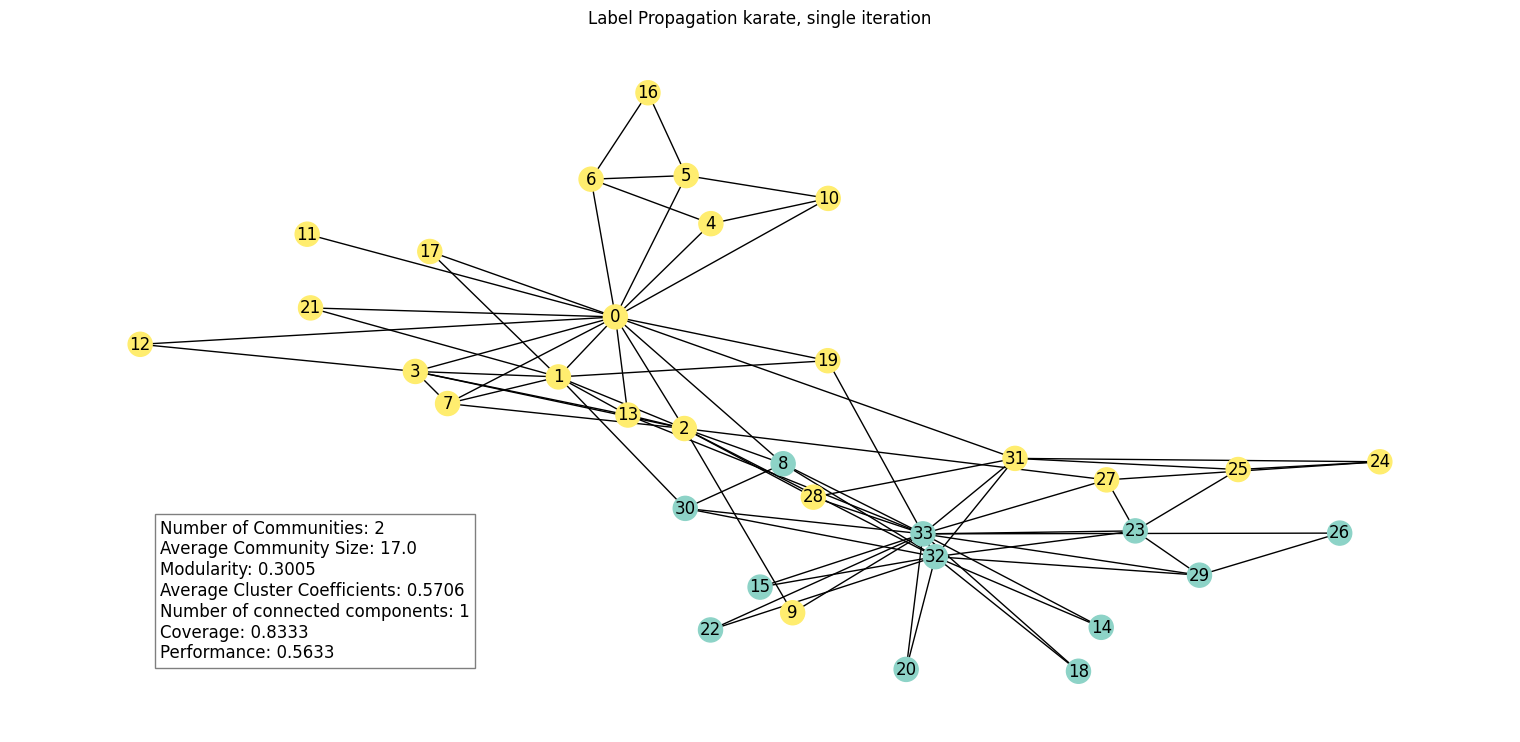

In [15]:
# single run
lp_labels = label_propagation(g, aggr_runs=5)

# Calculate metrics for LP
lp_metrics = community_metrics(g, lp_labels)
lp_trials.append({**lp_metrics, 'Iterations': 5})
plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, single iteration", metrics=lp_metrics)

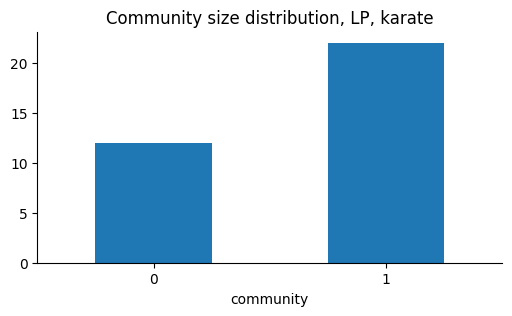

In [16]:
community_size_hist(lp_labels, title=f"Community size distribution, LP, {sel_graph}")

Experiments with 1, 5 and 15 iterations:

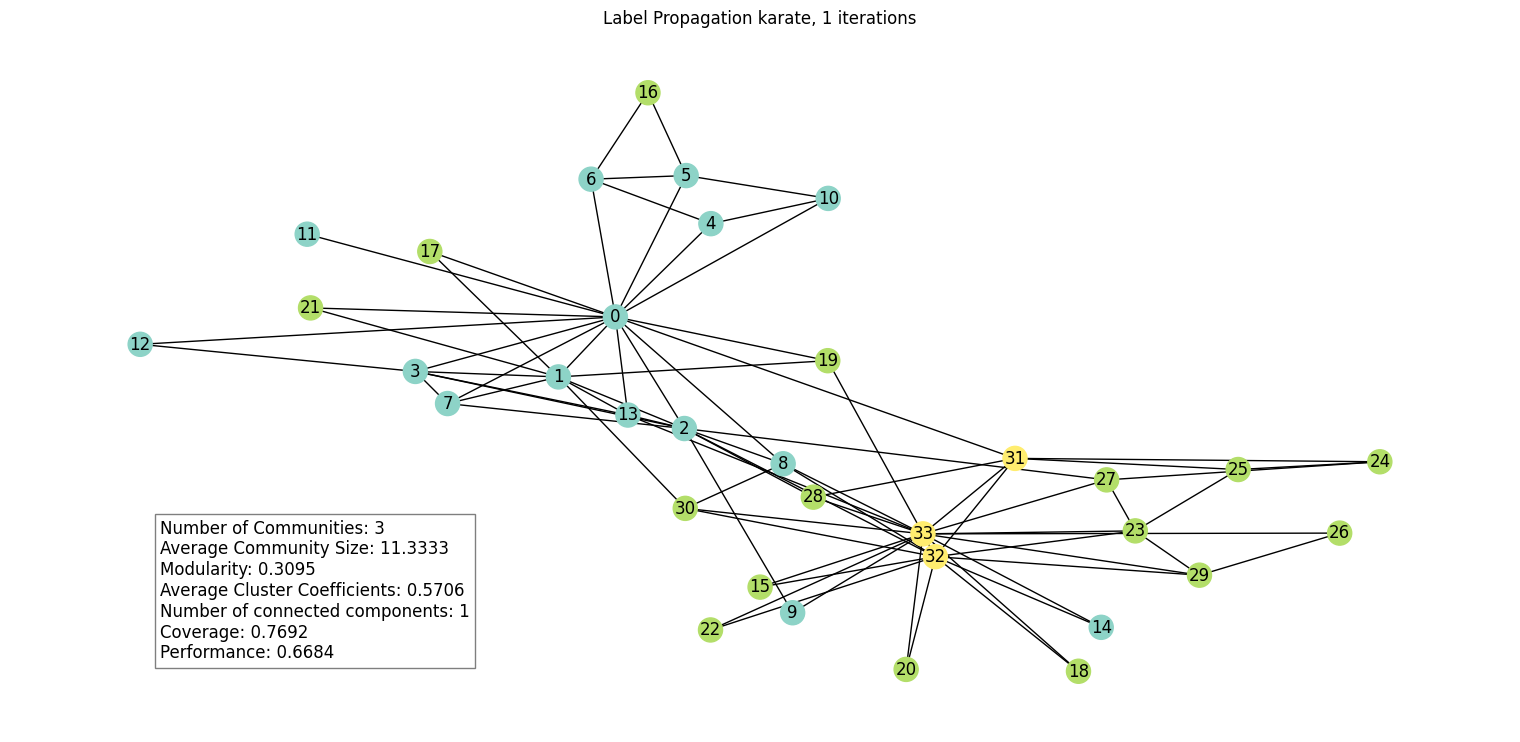

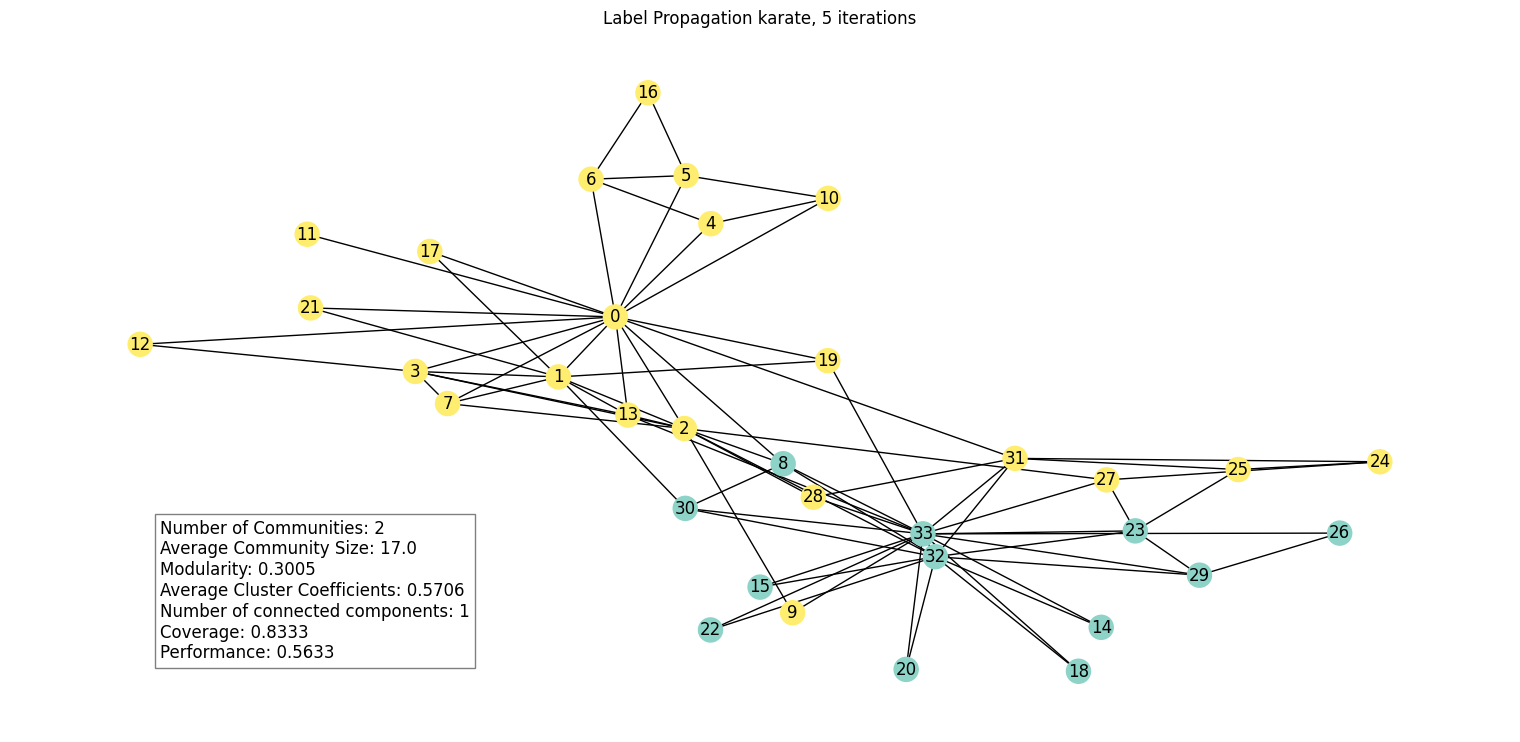

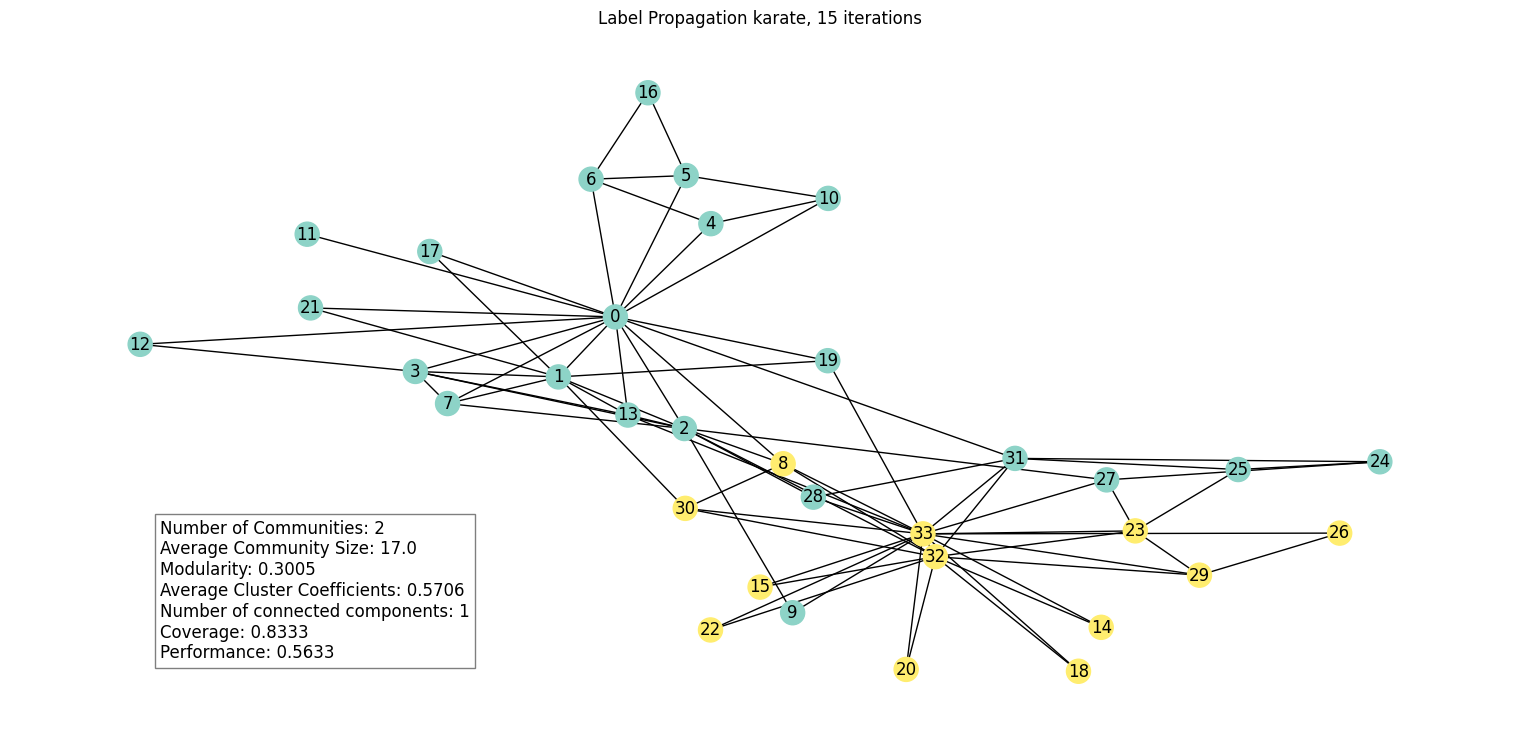

In [17]:
# based on results in paper, experiments with higher value 
# confirm authors' statement that modularity doesn't change much
for i in (1, 5, 15):
    lp_labels = label_propagation(g, aggr_runs=i)

    # Calculate metrics for LP
    lp_metrics = community_metrics(g, lp_labels)
    lp_trials.append({**lp_metrics, 'Iterations': i})
    plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}, {i} iterations", metrics=lp_metrics)

### Model evaluation

In [18]:
lp_df = pd.DataFrame(lp_trials)
best_num_iterations = int(lp_df.loc[lp_df['Modularity'].idxmax(), 'Iterations'])

# calculate execution time and metrics for best model
start_time = time.time()
lp_labels = label_propagation(g, aggr_runs=best_num_iterations)
end_time = time.time()
lp_time = end_time - start_time

lp_metrics = community_metrics(g, lp_labels)
lp_metrics["Iterations"] = best_num_iterations

## Louvain

### Hyperparameter selection

For Louvain algorithm, `resolution` hyperparameter will be tuned.

In [19]:
lv_trials = []

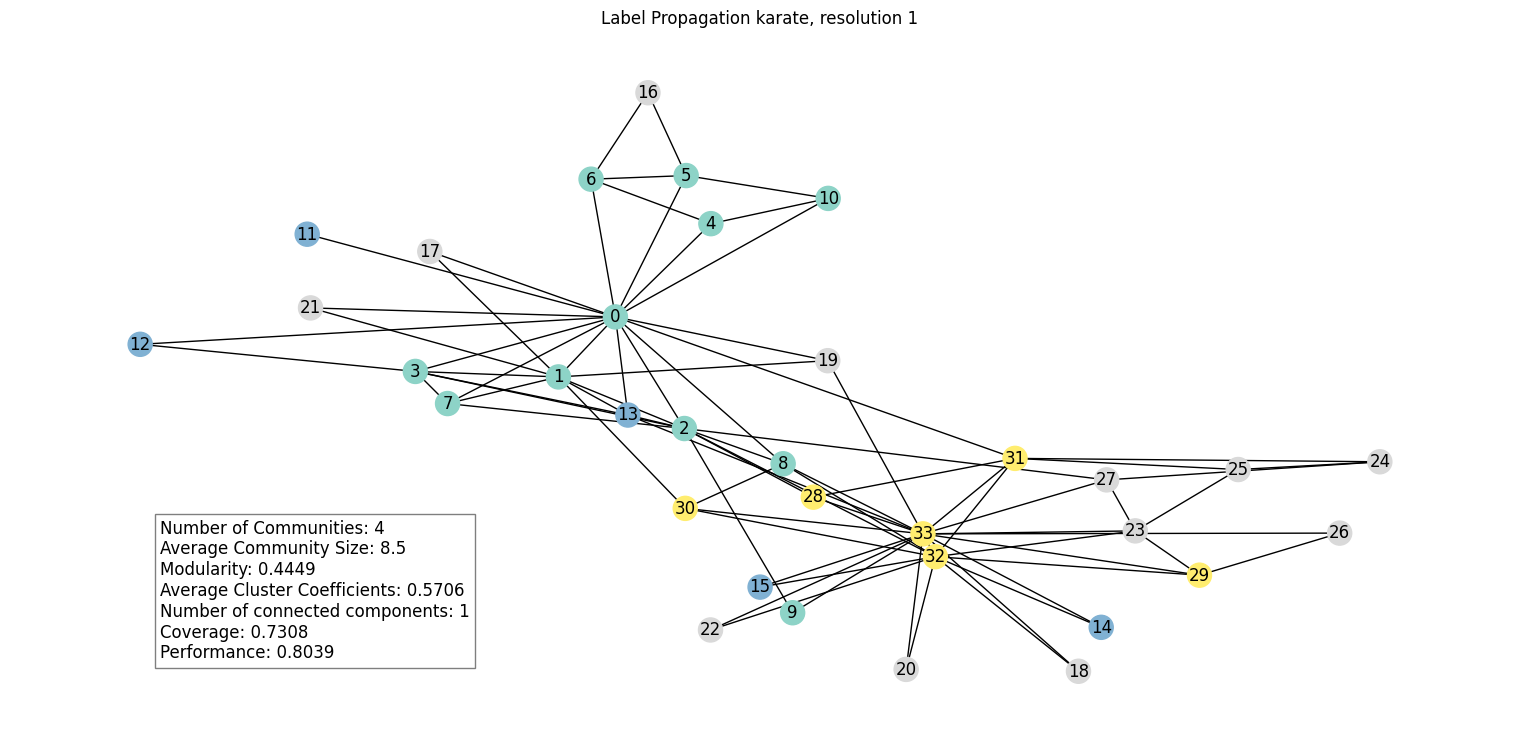

In [20]:
# default resolution
lv_labels = louvain(g, resolution=1)

# Calculate metrics for Louvain
lv_metrics = community_metrics(g, lv_labels)
lv_trials.append({**lv_metrics, 'Resolution': 1})
plot_communities(g, lv_labels, title=f"Label Propagation {sel_graph}, resolution 1", metrics=lv_metrics)

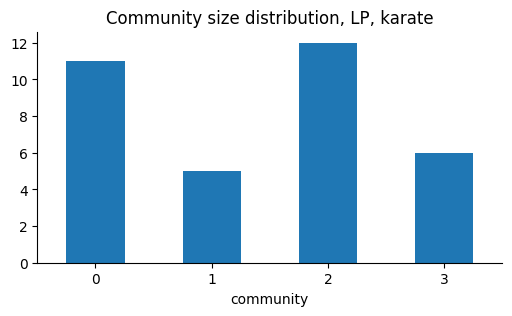

In [21]:
community_size_hist(lv_labels, title=f"Community size distribution, LP, {sel_graph}")

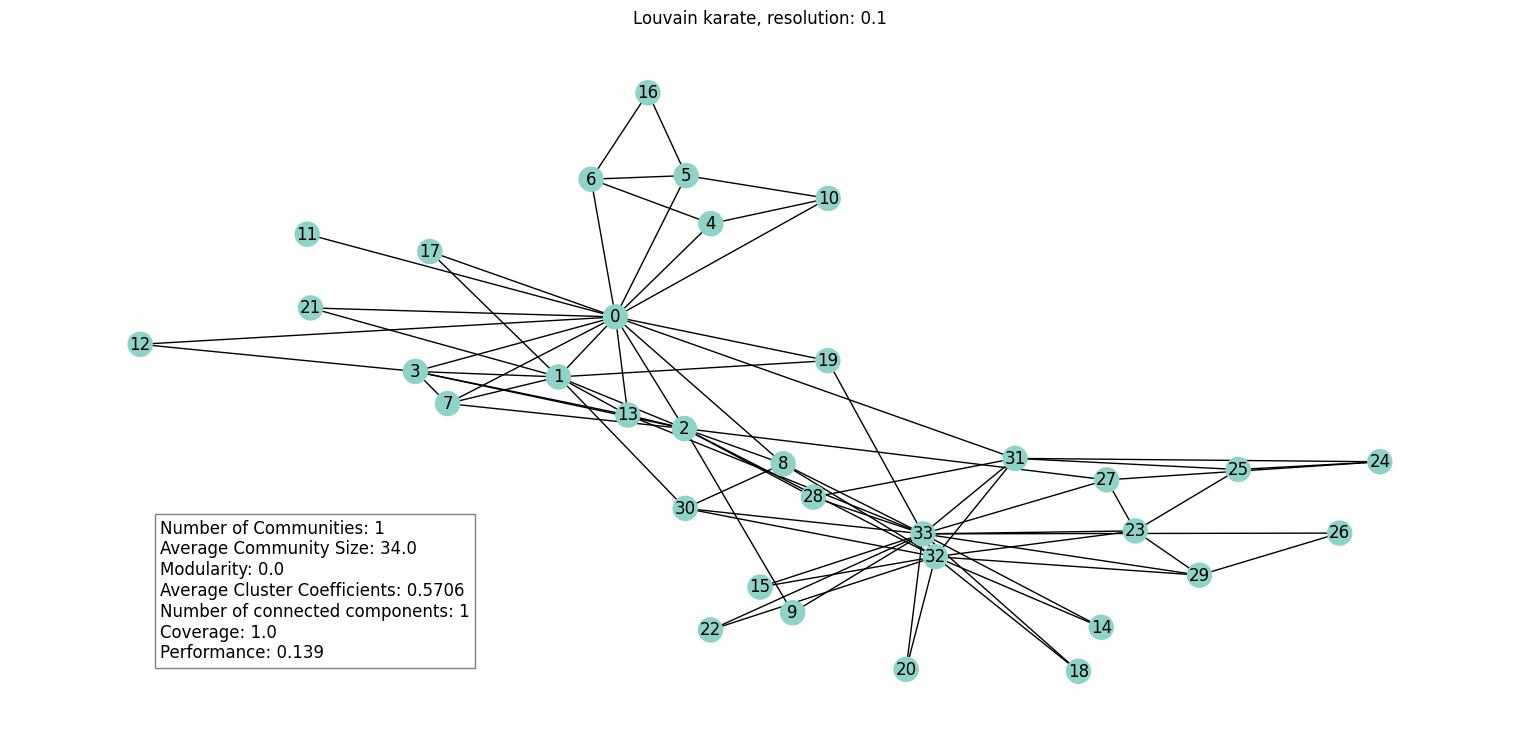

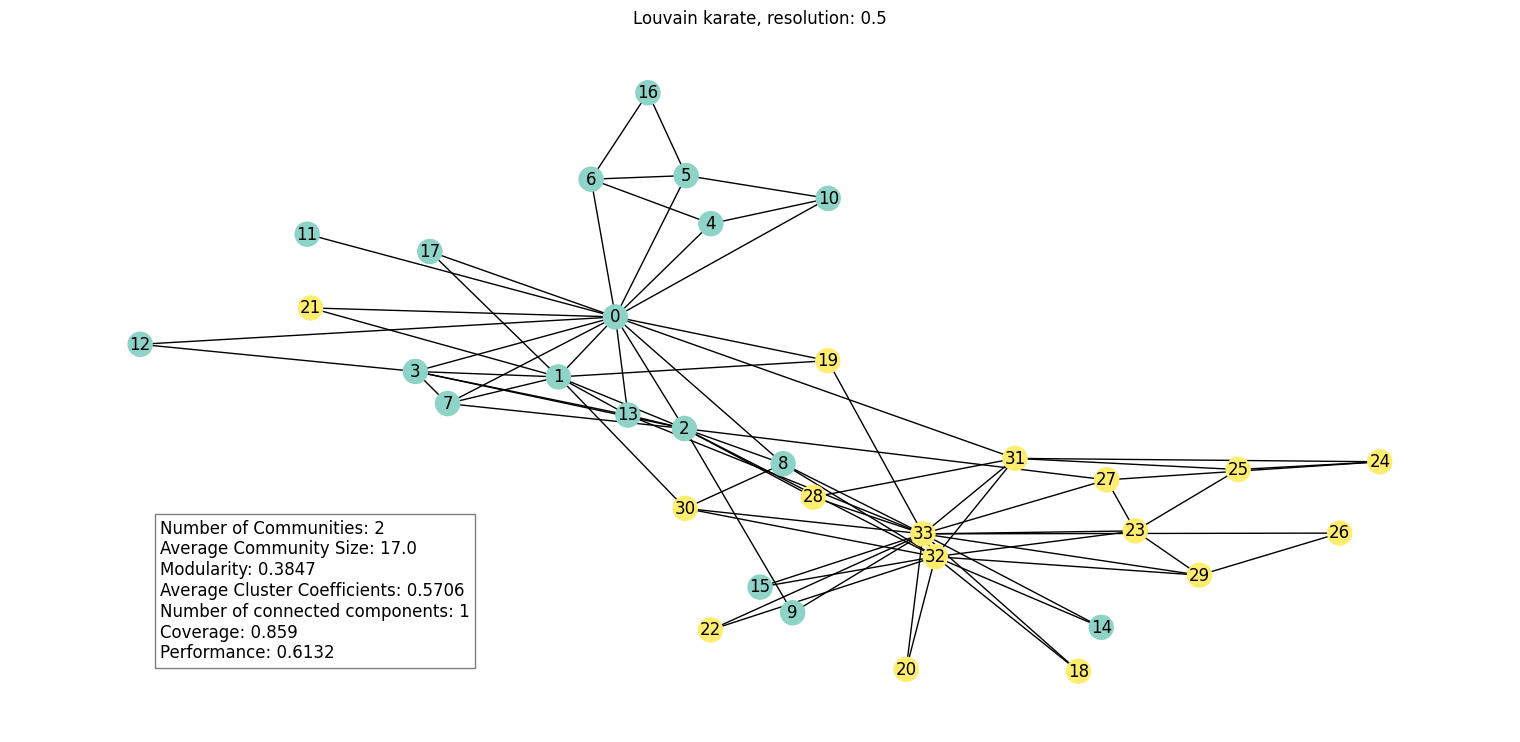

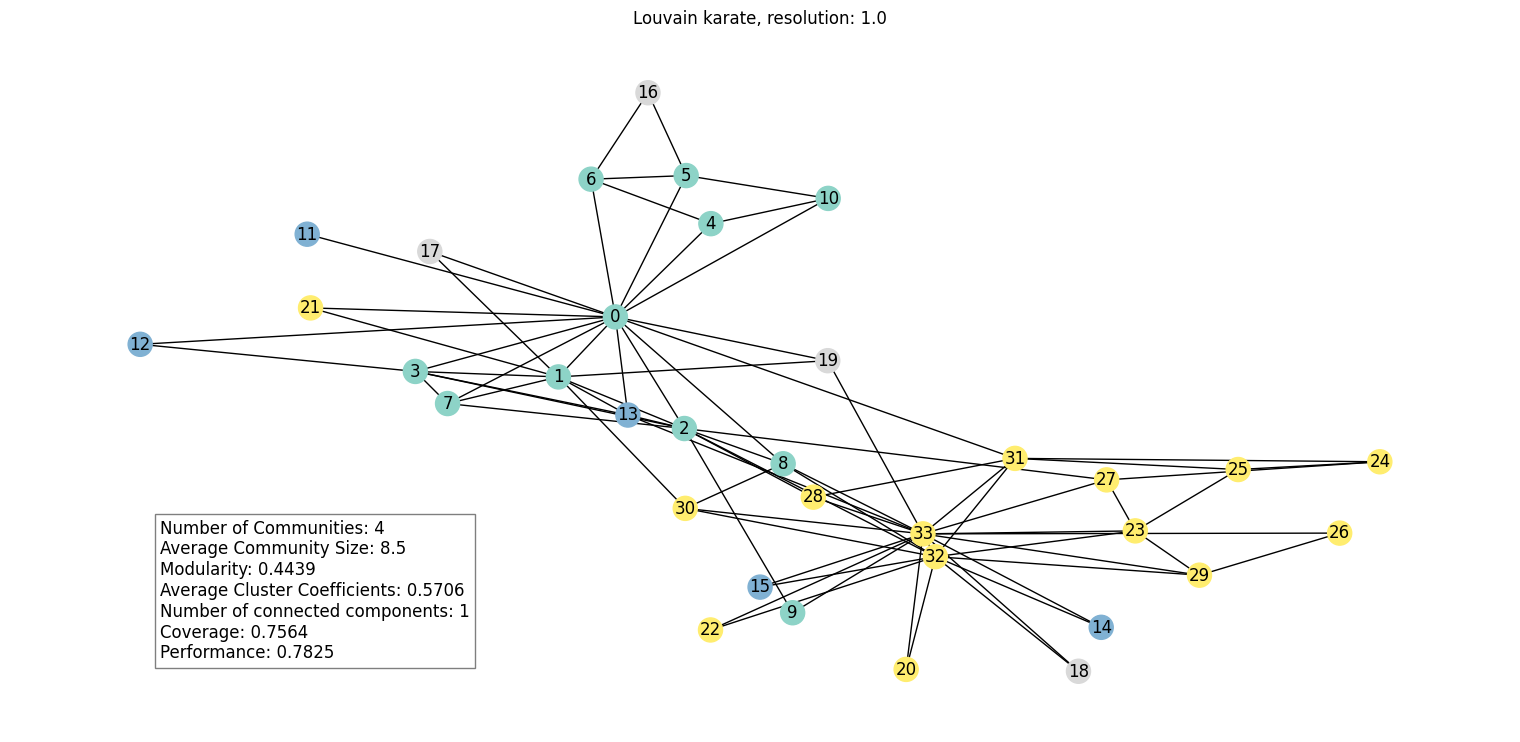

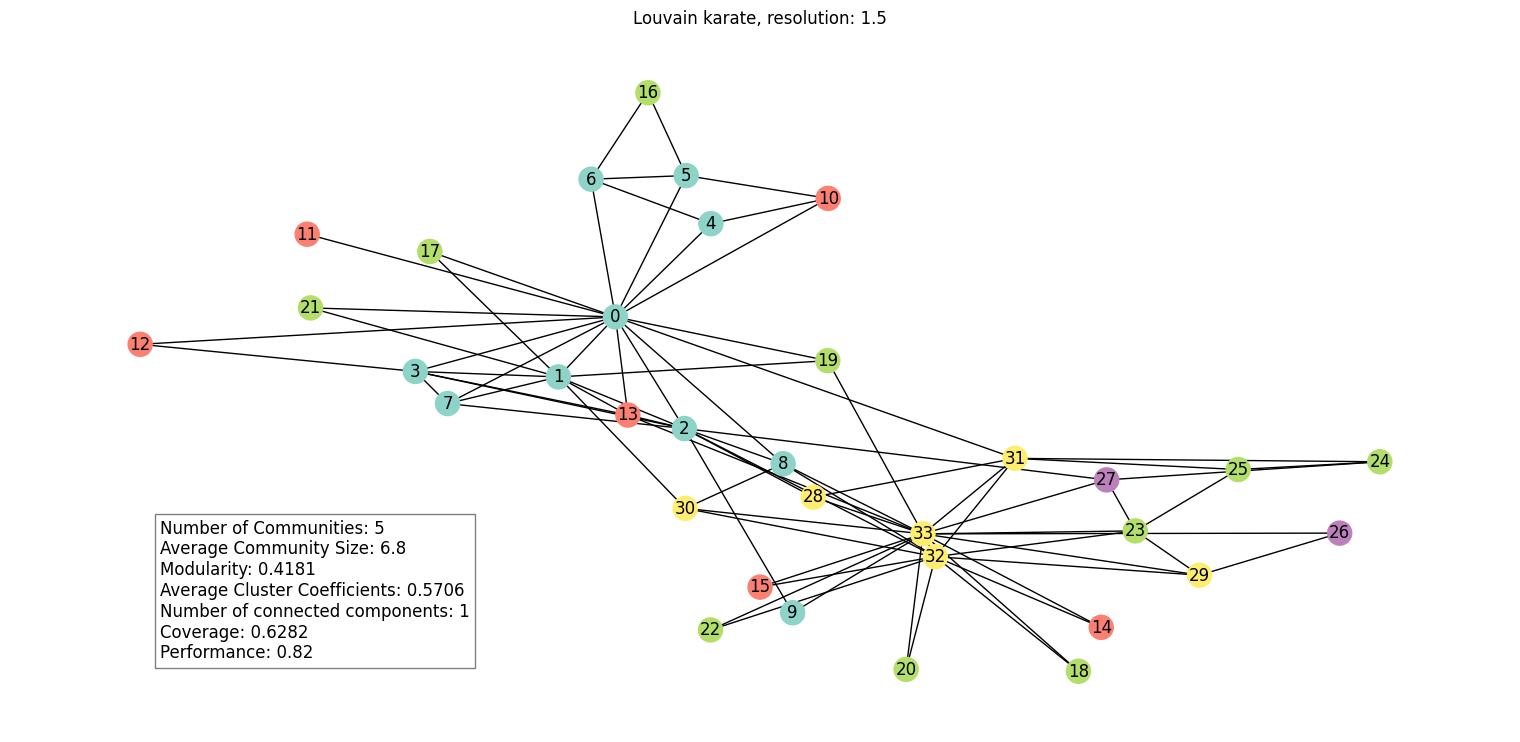

In [22]:
for i in (0.1, 0.5, 1.0, 1.5):
    lv_labels = louvain(g, resolution=i)

    # Calculate metrics for Louvain
    lv_metrics = community_metrics(g, lv_labels)
    lv_trials.append({**lv_metrics, 'Resolution': i})
    plot_communities(g, lv_labels, title=f"Louvain {sel_graph}, resolution: {i}", metrics=lv_metrics)

### Model evaluation

In [23]:
lv_df = pd.DataFrame(lv_trials)
best_resolution = lv_df.loc[lv_df['Modularity'].idxmax(), 'Resolution']

# calculate execution time and metrics for best model
start_time = time.time()
lv_labels = louvain(g, resolution=best_resolution)
end_time = time.time()
lv_time = end_time - start_time

lv_metrics = community_metrics(g, lv_labels)
lv_metrics["Resolution"] = best_resolution

## Leiden

### Hyperparameter selection

In [24]:
ld_trials = []

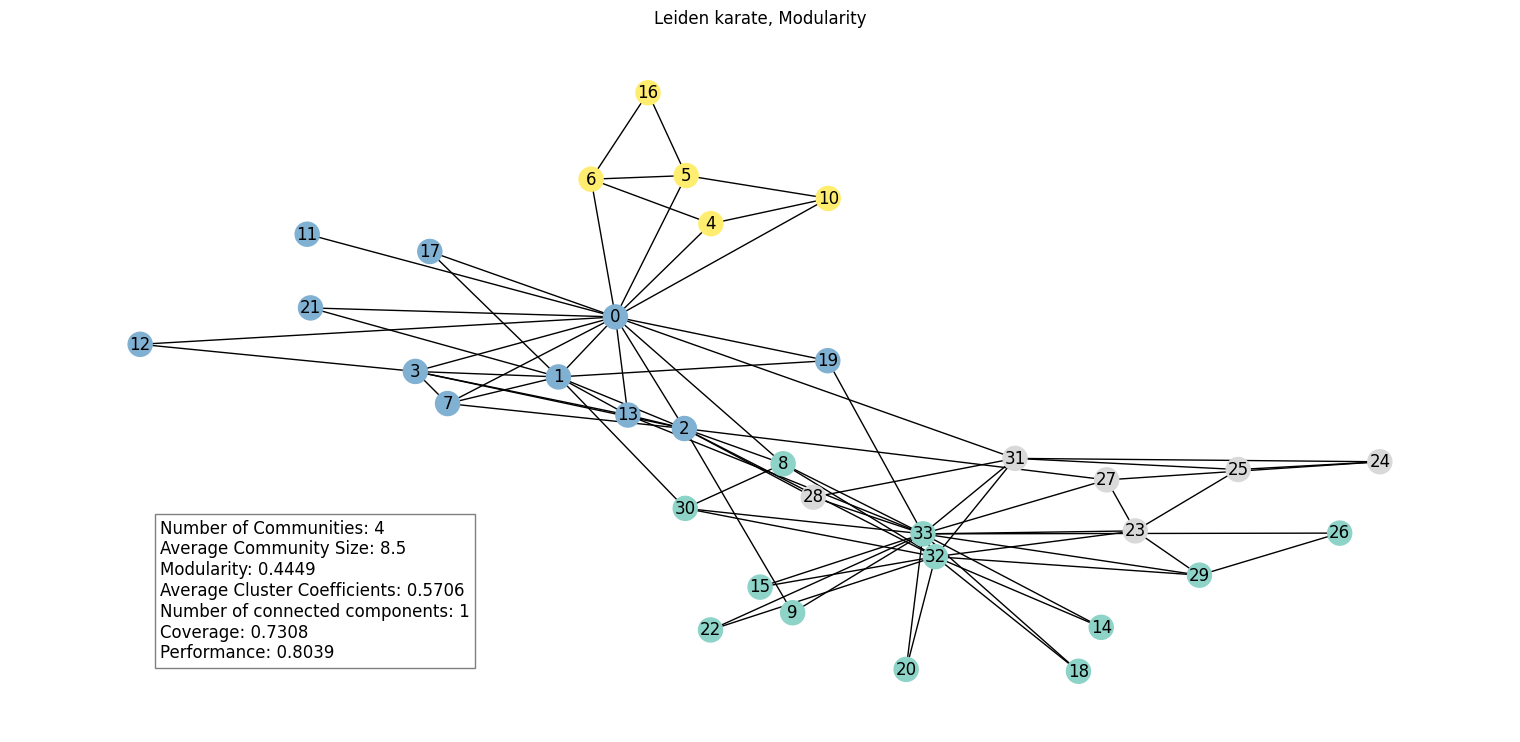

In [25]:
ld_labels = leiden(g)

# Calculate metrics for Leiden
ld_metrics = community_metrics(g, ld_labels)
ld_trials.append({**ld_metrics, 'Resolution': None})
plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, Modularity", metrics=ld_metrics)

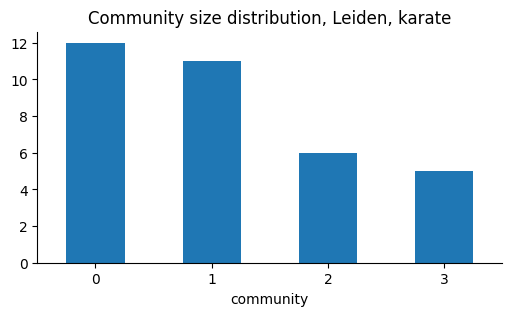

In [26]:
community_size_hist(ld_labels, title=f"Community size distribution, Leiden, {sel_graph}")

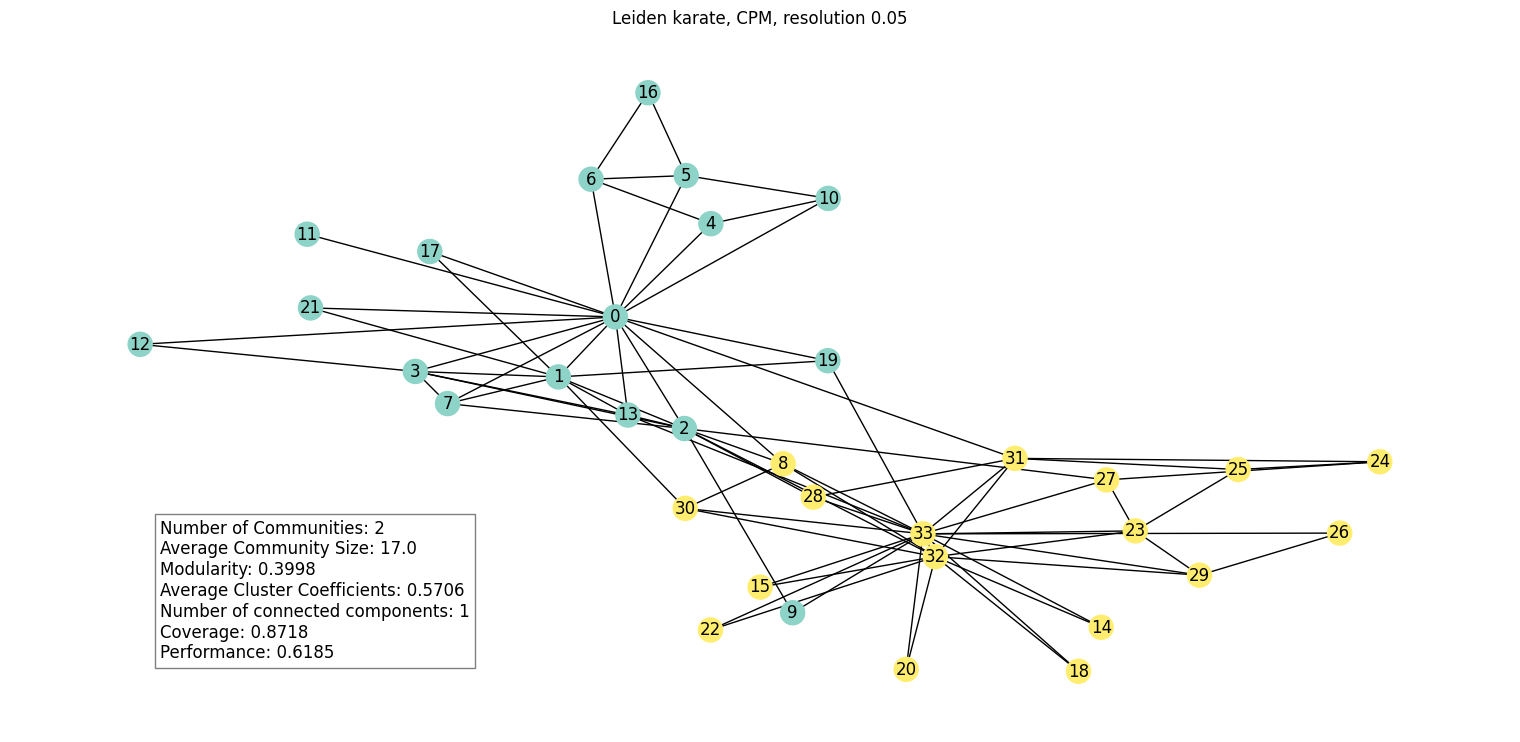

In [27]:
ld_labels = leiden(g, resolution=0.05)

# Calculate metrics for Leiden
ld_metrics = community_metrics(g, ld_labels)
ld_trials.append({**ld_metrics, 'Resolution': 0.05})
plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, CPM, resolution 0.05", metrics=ld_metrics)

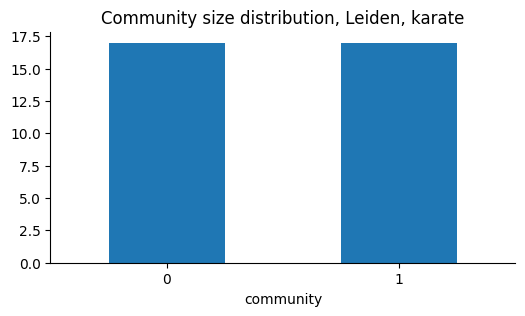

In [28]:
community_size_hist(ld_labels, title=f"Community size distribution, Leiden, {sel_graph}")

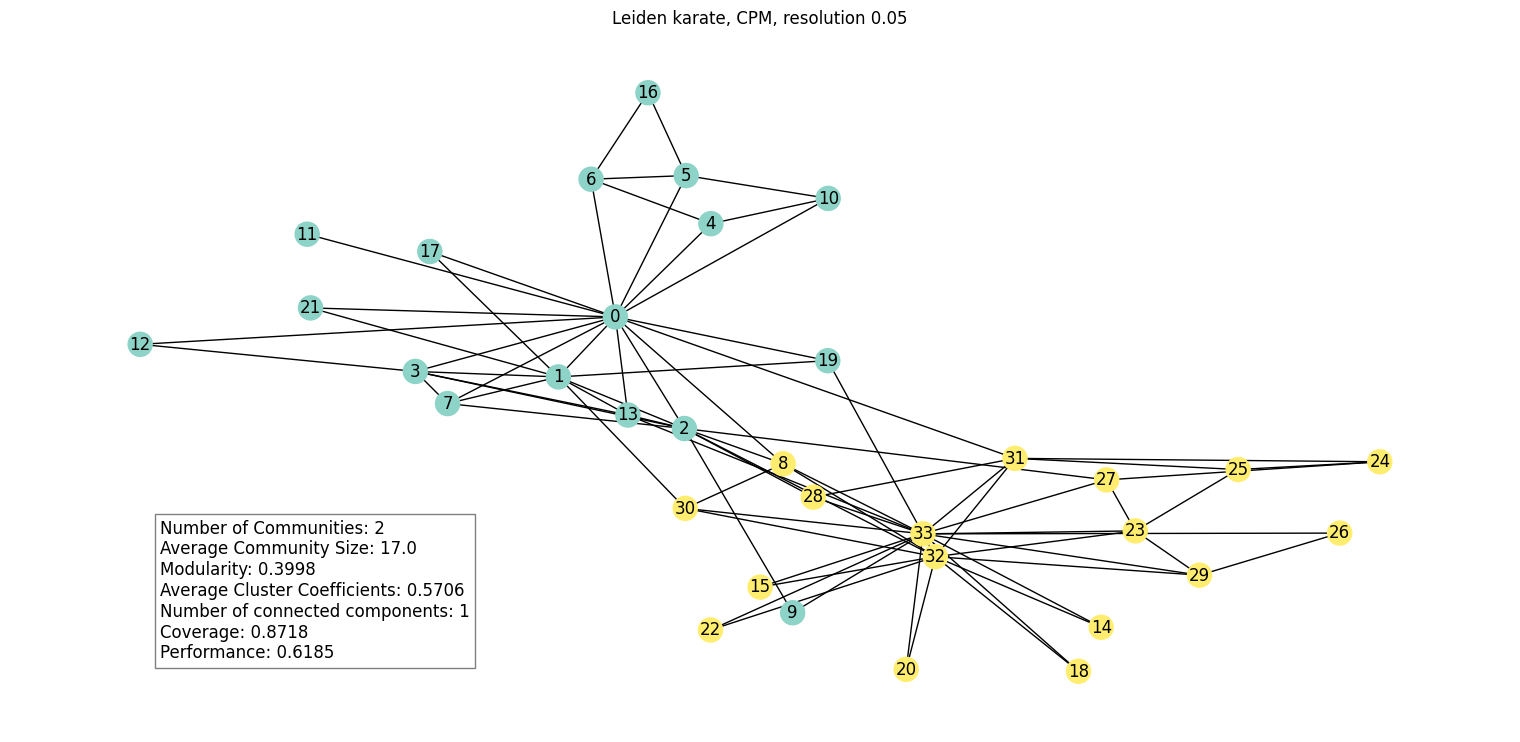

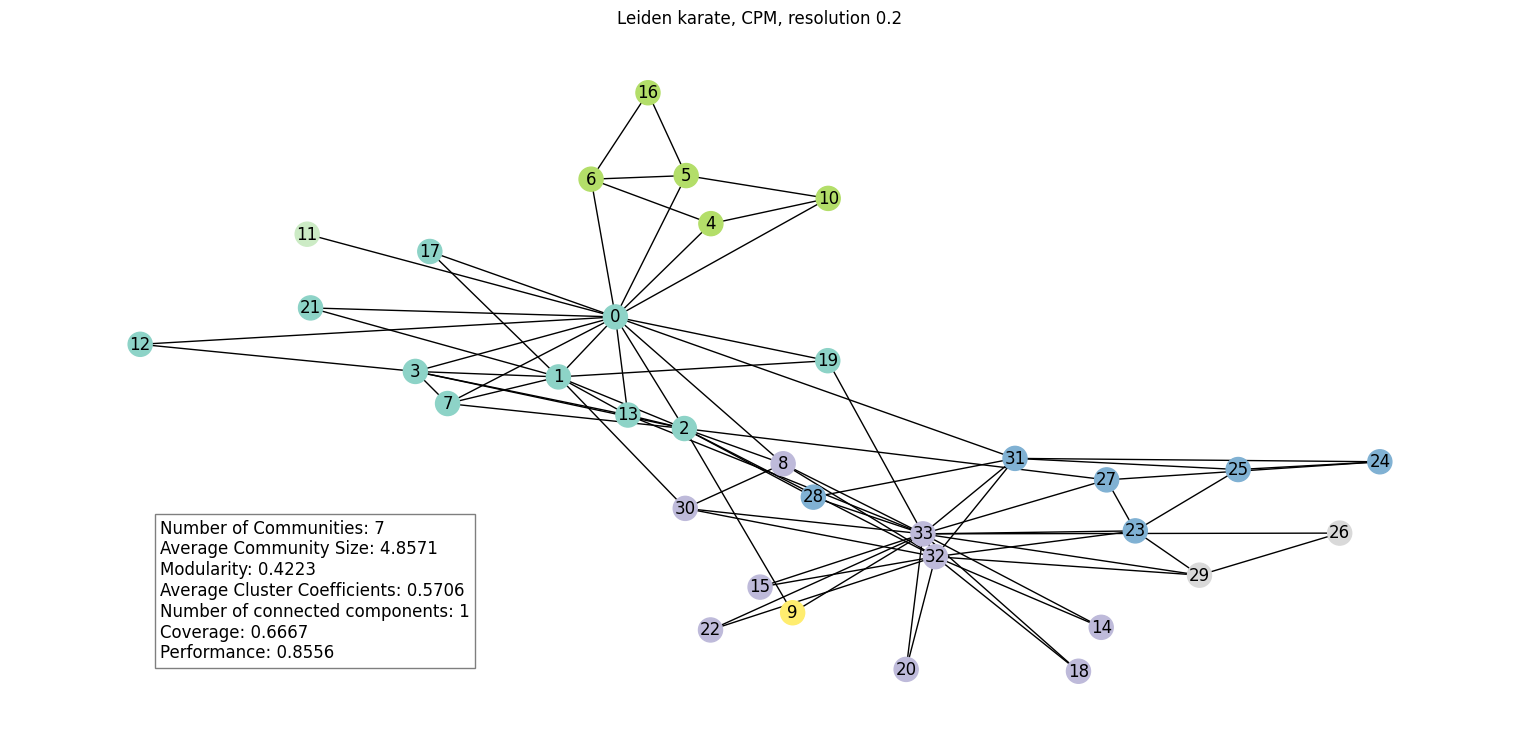

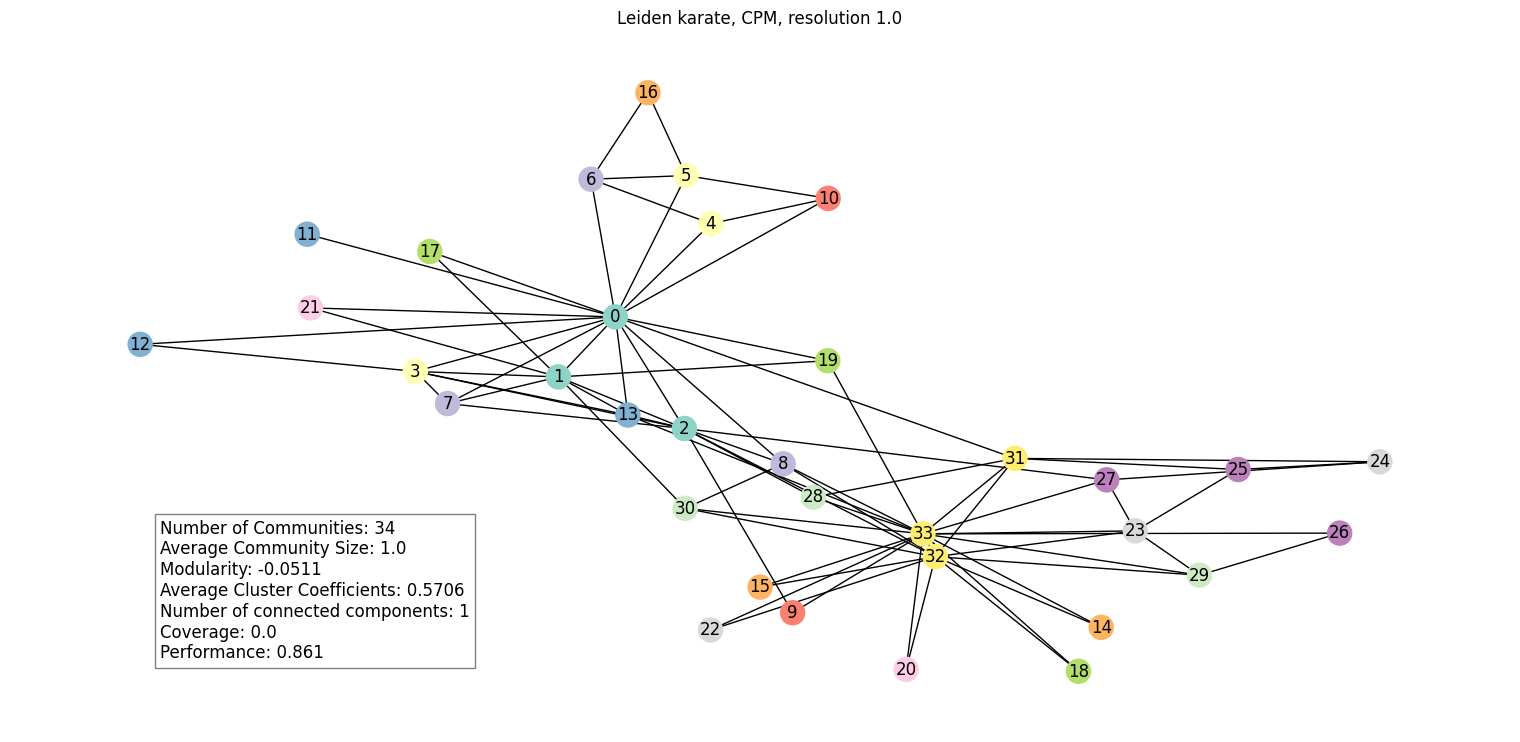

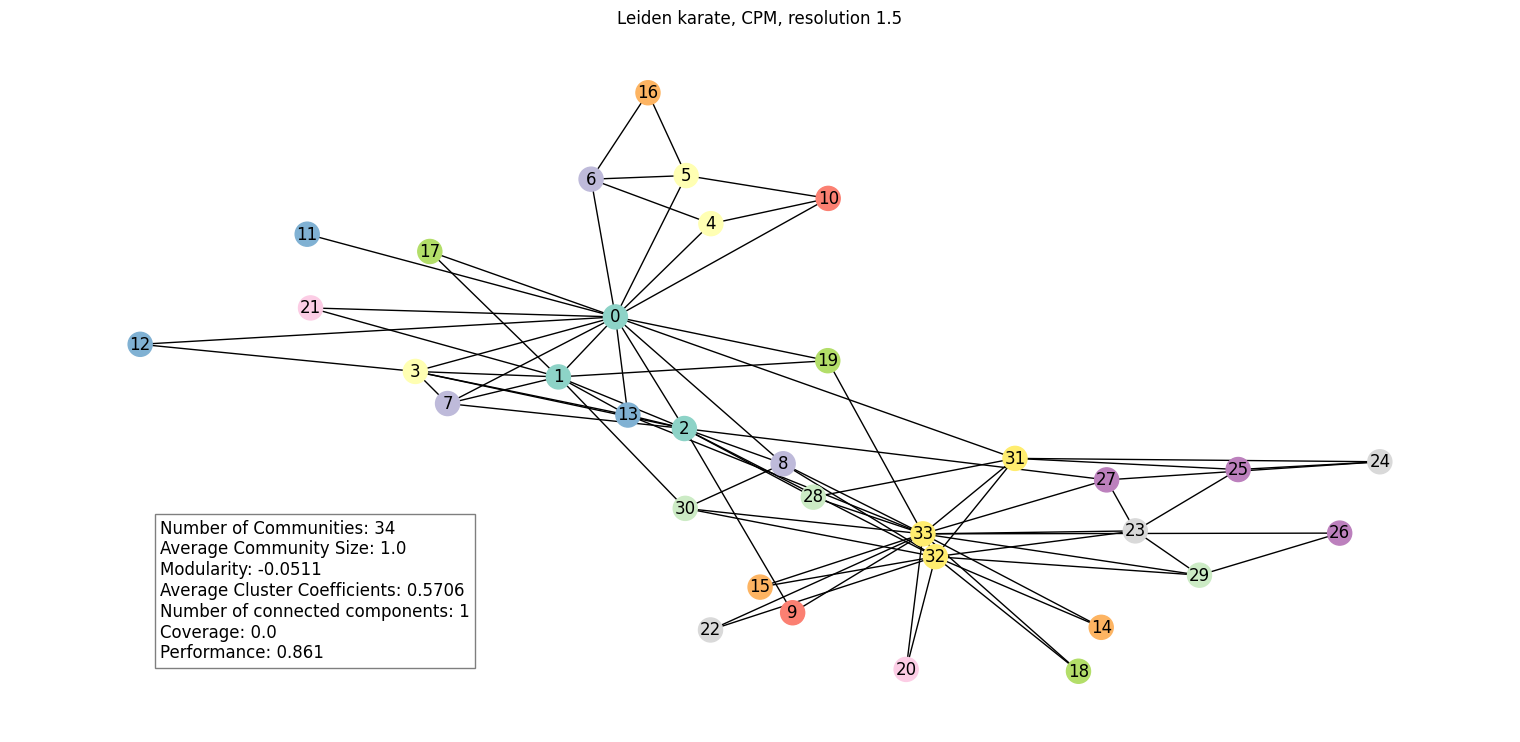

In [29]:
for i in (0.05, 0.2, 1.0, 1.5):
    ld_labels = leiden(g, resolution=i)

    # Calculate metrics for Leiden
    ld_metrics = community_metrics(g, ld_labels)
    ld_trials.append({**ld_metrics, 'Resolution': i})
    plot_communities(g, ld_labels, title=f"Leiden {sel_graph}, CPM, resolution {i}", metrics=ld_metrics)

### Model evaluation

In [30]:
ld_df = pd.DataFrame(ld_trials)
best_resolution = ld_df.loc[ld_df['Modularity'].idxmax(), 'Resolution']
if np.isnan(best_resolution):
    best_resolution = None

# calculate execution time and metrics for best model
start_time = time.time()
ld_labels = leiden(g, resolution=best_resolution)
end_time = time.time()
ld_time = end_time - start_time

ld_metrics = community_metrics(g, ld_labels)
ld_metrics["Resolution"] = best_resolution

# Apply GAT Embedding

We will try to train GAT using 3 different loss function and compare the obtained results. The loss functions are:
1. DGI (Deep Graph Infomax)
2. Embedding variance
3. Contrastive loss between connected and unconnected nodes


In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [32]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.eye(g.number_of_nodes(), dtype=torch.float)

In [33]:
def predict_with_time(data, model, train_function, epochs, best_clustering_method):
    """
    Helper function to train a model on a provided data with a given train function.
    Returns a tuple (obtained community predictions, time for prediction).
    """
    
    # Start timing
    start_time = time.time()
    
    # Training the model
    for epoch in range(epochs):
        loss = train_function()
        if epoch % 10 == 0:
            print(f'Epoch {epoch}, Loss: {loss}')
    
    # Extract node embeddings
    model.eval()
    with torch.no_grad():
        try:
            node_embeddings = model(data).detach().cpu().numpy()
        except AttributeError:  # case DGI
            node_embeddings = model.encoder(data.x, data.edge_index).cpu().numpy()
    
    if best_clustering_method == "optics":
        # optics clustering
        _, _, gat_communities = optics(g, node_embeddings)
    else:
        # kmeans clustering
        _, _, gat_communities = kmeans(g, node_embeddings)
    
    # End timing
    end_time = time.time()
    # Calculate the elapsed time
    elapsed_time = end_time - start_time

    return gat_communities, elapsed_time

## DGI loss

### Hyperparameter selection

In [34]:
# Select best hyperparameters
best_parameters_optuna_dgi = tune(data)

[I 2024-08-13 17:58:22,055] A new study created in memory with name: no-name-0d028251-07fa-40ee-9ed0-17328f720501
Best trial: 0. Best value: 0.359961: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  1.97it/s]


In [35]:
# Best observed modularity
best_parameters_optuna_dgi.best_value

0.3599605522682445

In [36]:
# Save best params
best_parameters = best_parameters_optuna_dgi.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 100
num_layers = 2

best_method = best_parameters_optuna_dgi.best_trial.user_attrs['best_method']

### Model evaluation

In [37]:
# Define DGI model, optimizer, train function for DGI with optimal params
model = DGIModel(in_channels=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_layers=num_layers, heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)


def train():
    model.train()
    optimizer.zero_grad()
    pos_z, neg_z, summary = model(data)
    loss = model.dgi.loss(pos_z, neg_z, summary)
    loss.backward()
    optimizer.step()
    return loss.item()

In [38]:
# get predictions with best model and record time spent on that
gat_dgi_communities, time_dgi = predict_with_time(data, model, train, epochs, best_method)

Epoch 0, Loss: 1.407732605934143
Epoch 10, Loss: 1.398414134979248
Epoch 20, Loss: 1.3750481605529785
Epoch 30, Loss: 1.3545129299163818
Epoch 40, Loss: 1.3692388534545898
Epoch 50, Loss: 1.3704485893249512
Epoch 60, Loss: 1.3722734451293945
Epoch 70, Loss: 1.347928762435913
Epoch 80, Loss: 1.342271327972412
Epoch 90, Loss: 1.3387335538864136


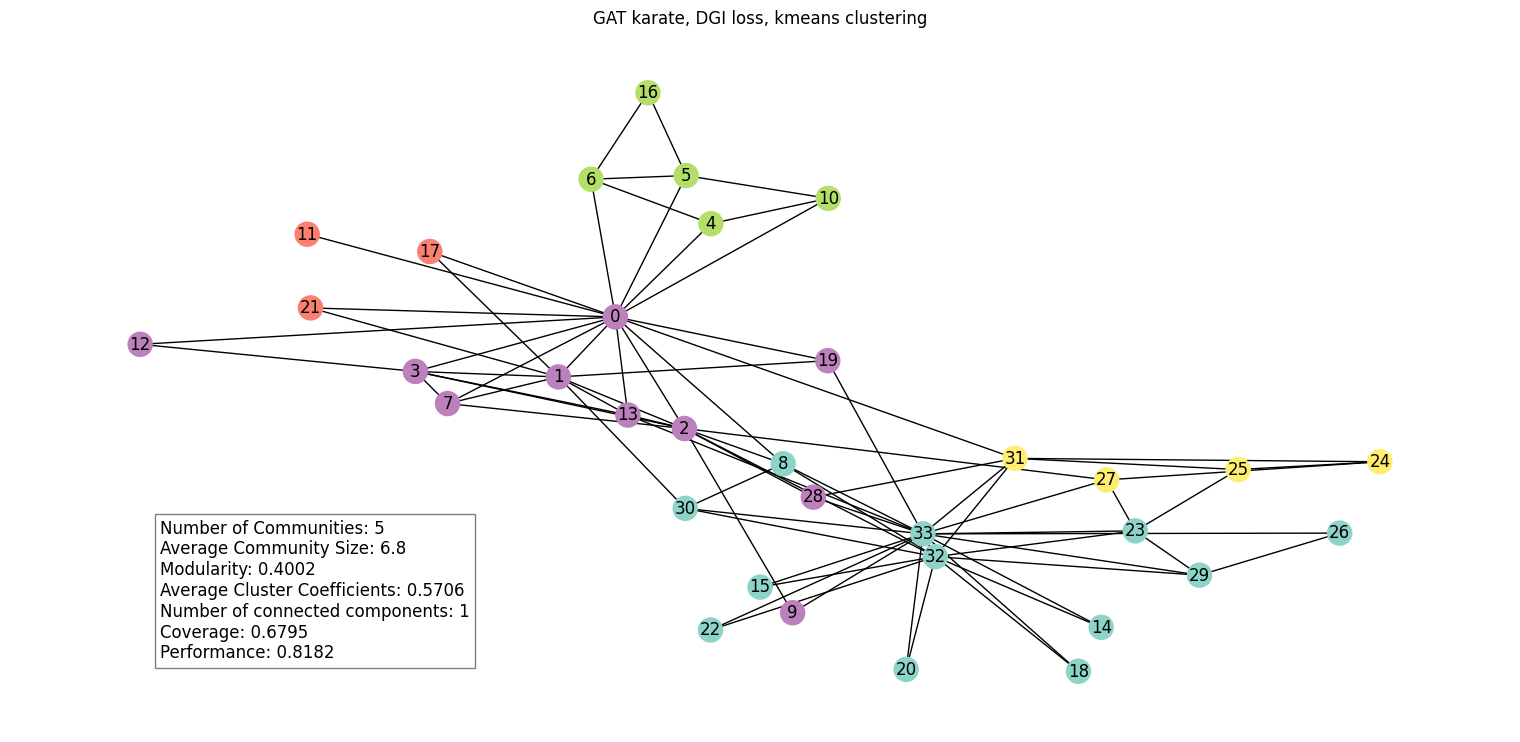

In [39]:
# Print results for the best parameters and best clustering method
gat_dgi_metrics = community_metrics(g, gat_dgi_communities)
plot_communities(g, gat_dgi_communities, title=f"GAT {sel_graph}, DGI loss, {best_method} clustering", metrics=gat_dgi_metrics)

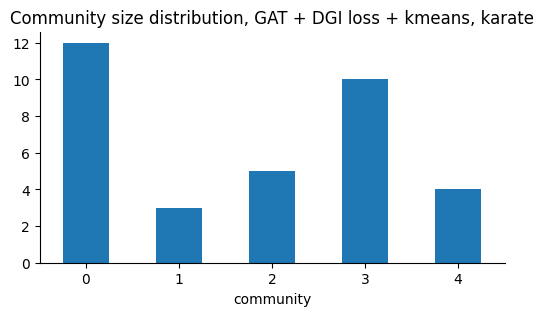

In [40]:
community_size_hist(gat_dgi_communities, title=f"Community size distribution, GAT + DGI loss + {best_method}, {sel_graph}")

## Embedding variance loss

### Hyperparameter selection

In [41]:
best_parameters_optuna_var = tune_variance_contrastive(data, g, loss_function="variance")

In [42]:
# Best observed modularity
best_parameters_optuna_var.best_value

0.39865257397724935

In [43]:
best_parameters = best_parameters_optuna_var.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 100
num_layers = 2

best_method = best_parameters_optuna_var.best_trial.user_attrs['best_method']

### Model evaluation

In [44]:
# Define GAT model with embedding variance loss functions
# Define optimizer, train function for GAT with optimal params
model = GAT(num_features=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = -torch.var(out)
    loss.backward()
    optimizer.step()
    return loss.item()

In [45]:
# get predictions with best model and record time spent on that
gat_var_communities, time_var = predict_with_time(data, model, train, epochs, best_method)

Epoch 0, Loss: -0.004303763620555401
Epoch 10, Loss: -0.008462299592792988
Epoch 20, Loss: -0.015600228682160378
Epoch 30, Loss: -0.023194871842861176
Epoch 40, Loss: -0.03733997046947479
Epoch 50, Loss: -0.07877971976995468
Epoch 60, Loss: -0.13740761578083038
Epoch 70, Loss: -0.16287748515605927
Epoch 80, Loss: -0.423155277967453
Epoch 90, Loss: -0.6919127702713013


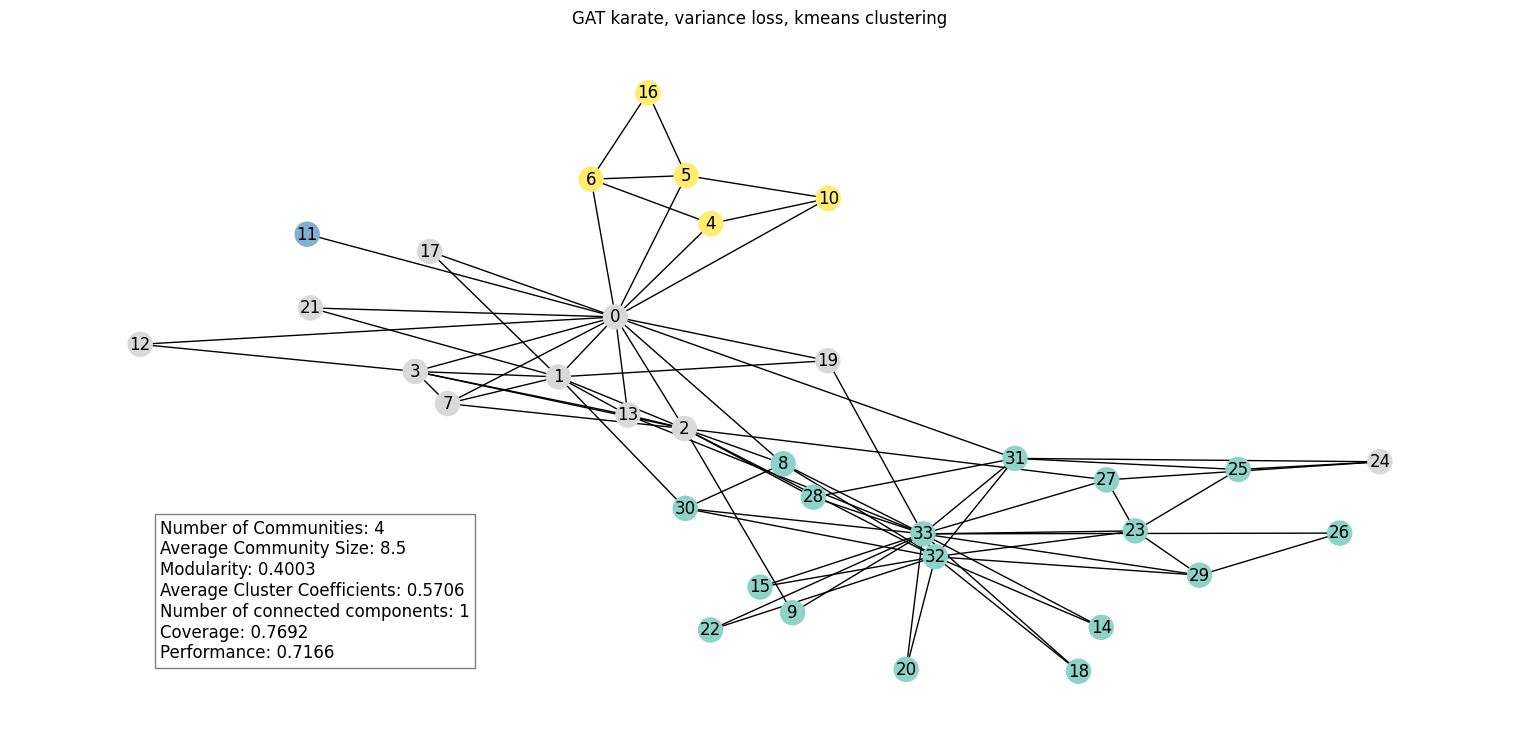

In [46]:
# get visualizations and metrics
gat_var_metrics = community_metrics(g, gat_var_communities)
plot_communities(g, gat_var_communities, title=f"GAT {sel_graph}, variance loss, {best_method} clustering", metrics=gat_var_metrics)

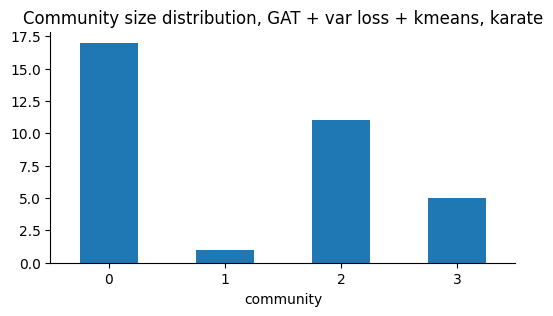

In [47]:
community_size_hist(gat_var_communities, title=f"Community size distribution, GAT + var loss + {best_method}, {sel_graph}")

## Contrastive loss

### Hyperparameter selection

In [48]:
best_parameters_optuna_con = tune_variance_contrastive(data, g, loss_function="contrastive")

In [49]:
# Best observed modularity
best_parameters_optuna_con.best_value

0.4345214669889994

In [50]:
best_parameters = best_parameters_optuna_con.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 100

best_clustering_method = best_parameters_optuna_con.best_trial.user_attrs['best_method']

### Model evaluation

In [51]:
# Define GAT model with contrastive loss functions
# Define optimizer, train function for GAT with optimal params

model = GAT(num_features=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = contrastive_loss(out, g)
    loss.backward()
    optimizer.step()
    return loss.item()

In [52]:
gat_con_communities, time_con = predict_with_time(data, model, train, epochs, best_method)

Epoch 0, Loss: 0.33859890699386597
Epoch 10, Loss: 0.1495351940393448
Epoch 20, Loss: 0.06284450739622116
Epoch 30, Loss: 0.08345288038253784
Epoch 40, Loss: 0.06908152997493744
Epoch 50, Loss: 0.06679470837116241
Epoch 60, Loss: 0.07409804314374924
Epoch 70, Loss: 0.06336332112550735
Epoch 80, Loss: 0.05144929513335228
Epoch 90, Loss: 0.05563947558403015


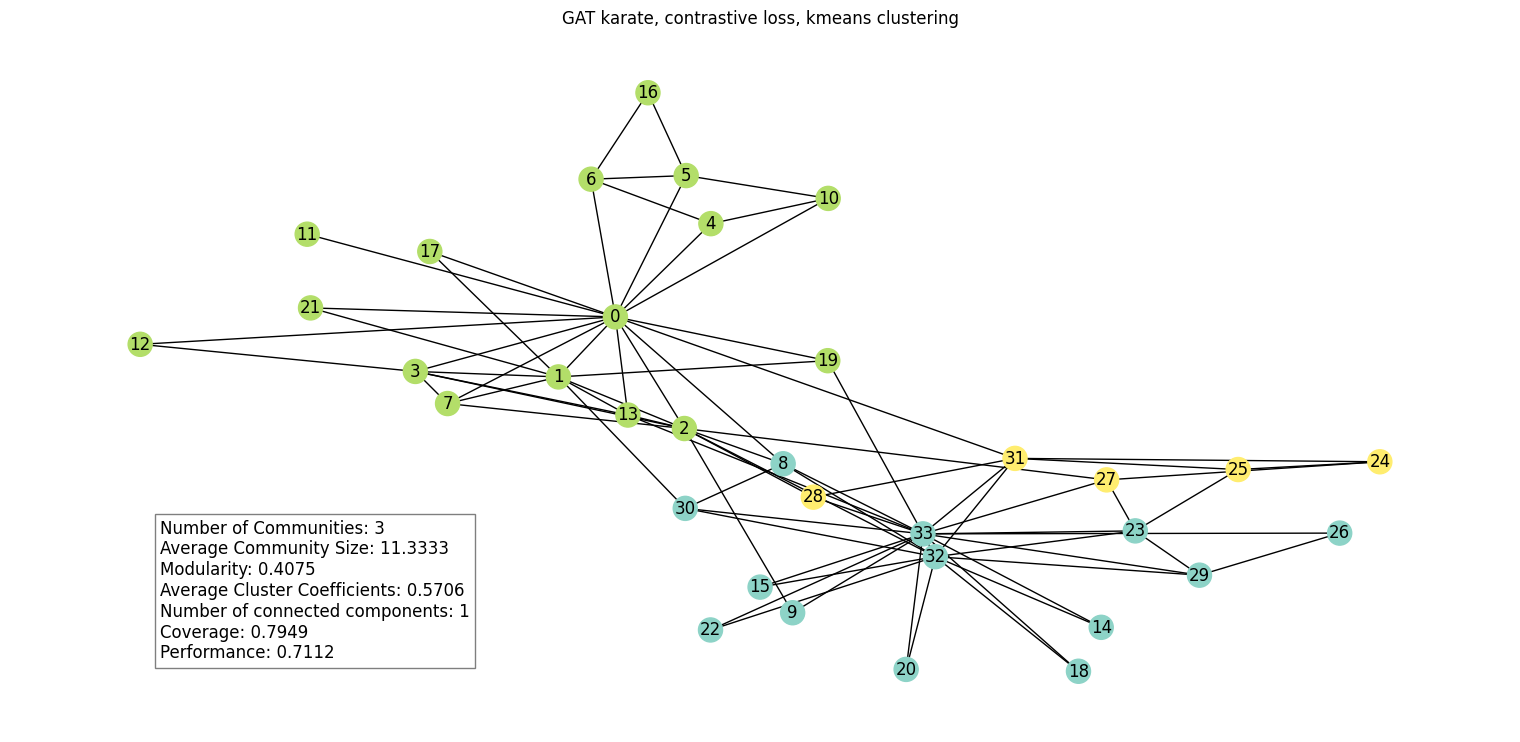

In [53]:
gat_con_metrics = community_metrics(g, gat_con_communities)
plot_communities(g, gat_con_communities, title=f"GAT {sel_graph}, contrastive loss, {best_method} clustering", metrics=gat_con_metrics)

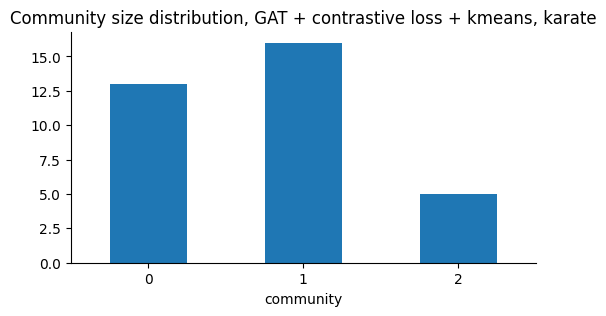

In [54]:
community_size_hist(gat_con_communities, title=f"Community size distribution, GAT + contrastive loss + {best_method}, {sel_graph}")

# Final result

## Metrics

In [55]:
lp_metrics["Algorithm"] = "Label Propagation"
lv_metrics["Algorithm"] = "Louvaine"
ld_metrics["Algorithm"] = "Leiden"
gat_dgi_metrics["Algorithm"] = "GAT + DGI loss"
gat_var_metrics["Algorithm"] = "GAT + variance loss"
gat_con_metrics["Algorithm"] = "GAT + contrastive loss"

for metrics_ in [gat_dgi_metrics, gat_var_metrics, gat_con_metrics]:
    metrics_["Iterations"] = pd.NA
    metrics_["Resolution"] = pd.NA

lp_metrics["Resolution"] = pd.NA
lv_metrics["Iterations"] = pd.NA
ld_metrics["Iterations"] = pd.NA

In [56]:
final_metrics = {key: [] for key, value in lp_metrics.items()}
for metrics_ in [lp_metrics, lv_metrics, ld_metrics, gat_dgi_metrics, gat_var_metrics, gat_con_metrics]:
    for key, value in metrics_.items():
        final_metrics[key].append(value)

In [57]:
final_metrics = pd.DataFrame.from_dict(final_metrics).set_index("Algorithm").drop(["Average Cluster Coefficients", "Number of connected components"], axis=1)
final_metrics.style.format(precision=3).background_gradient(cmap='Blues', axis=None)

,Number of Communities,Average Community Size,Modularity,Coverage,Performance,Iterations,Resolution
Algorithm,,,,,,,
Label Propagation,3,11.333,0.309,0.769,0.668,1,
Louvaine,4,8.500,0.445,0.731,0.804,,1.000
Leiden,4,8.500,0.445,0.731,0.804,,None
GAT + DGI loss,5,6.800,0.400,0.679,0.818,,
GAT + variance loss,4,8.500,0.400,0.769,0.717,,
GAT + contrastive loss,3,11.333,0.408,0.795,0.711,,


## Execution times (CPU)

In [58]:
times = dict(zip(final_metrics.index, [[value] for value in [lp_time, lv_time, ld_time, time_dgi, time_var, time_con]]))

In [59]:
time_metrics = pd.DataFrame.from_dict(times)
time_metrics.index = ["Elapsed time, seconds"]

In [60]:
time_metrics.style.format(precision=4).background_gradient(cmap='Blues', axis=None)

,Label Propagation,Louvaine,Leiden,GAT + DGI loss,GAT + variance loss,GAT + contrastive loss
"Elapsed time, seconds",0.0002,0.0010,0.0013,0.2602,0.1717,1.8505


## Optuna best hyperparameters for GAT

In [61]:
dgi = best_parameters_optuna_dgi.best_params
var = best_parameters_optuna_var.best_params
con = best_parameters_optuna_con.best_params

In [62]:
best_hyperparams = {key: [] for key, value in dgi.items()}
for params in [dgi, var, con]:
    for key, value in params.items():
        best_hyperparams[key].append(value)

In [63]:
best_hyperparams = pd.DataFrame.from_dict(best_hyperparams)
best_hyperparams.index = ["GAT + DGI loss", "GAT + variance loss", "GAT + contrastive loss"]
best_hyperparams.style.format(precision=6).background_gradient(cmap='Blues', axis=None)

,hidden_channels,out_channels,heads,learning_rate,dropout,weight_decay
GAT + DGI loss,18,8,5,0.000312,0.140998,0.000049
GAT + variance loss,8,30,10,0.000621,0.365788,0.000415
GAT + contrastive loss,25,11,3,0.004443,0.471873,0.000222
